In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()
print("Libraries imported successfully")

Libraries imported successfully


In [32]:
# Load the dataset
df = pd.read_csv("/Users/shivanirawat/Desktop/Retail_Sales_Profit_Analysis/SuperStoreOrders.csv")
df.head()
print(df.head(5))

          order_id order_date ship_date       ship_mode    customer_name  \
0     AG-2011-2040   1/1/2011  6/1/2011  Standard Class  Toby Braunhardt   
1    IN-2011-47883   1/1/2011  8/1/2011  Standard Class      Joseph Holt   
2     HU-2011-1220   1/1/2011  5/1/2011    Second Class    Annie Thurman   
3  IT-2011-3647632   1/1/2011  5/1/2011    Second Class     Eugene Moren   
4    IN-2011-47883   1/1/2011  8/1/2011  Standard Class      Joseph Holt   

       segment            state    country  market   region  ...  \
0     Consumer      Constantine    Algeria  Africa   Africa  ...   
1     Consumer  New South Wales  Australia    APAC  Oceania  ...   
2     Consumer         Budapest    Hungary    EMEA     EMEA  ...   
3  Home Office        Stockholm     Sweden      EU    North  ...   
4     Consumer  New South Wales  Australia    APAC  Oceania  ...   

          category sub_category                 product_name sales quantity  \
0  Office Supplies      Storage          Tenex Lockers,

In [33]:
# Basic info
print("\nShape of dataset:")
print(df.shape)
print("\Column Names:")
print(df.columns)
print("\nDataset Info:")
print(df.info())


Shape of dataset:
(51290, 21)
\Column Names:
Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='str')

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  str    
 1   order_date      51290 non-null  str    
 2   ship_date       51290 non-null  str    
 3   ship_mode       51290 non-null  str    
 4   customer_name   51290 non-null  str    
 5   segment         51290 non-null  str    
 6   state           51290 non-null  str    
 7   country         51290 non-null  str    
 8   market          51290 non-null  str    
 9   region          51290 non-nul

<>:4: SyntaxWarning: invalid escape sequence '\C'
<>:4: SyntaxWarning: invalid escape sequence '\C'
/var/folders/4x/083nxg790kddspnh47ylqc3m0000gn/T/ipykernel_2130/652556627.py:4: SyntaxWarning: invalid escape sequence '\C'
  print("\Column Names:")


In [34]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values per column:
order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

Total missing values: 0


In [35]:
# Check for duplicates
print("Number of duplicate rows:", df.duplicated().sum())

# Remove duplicates if found
df.drop_duplicates(inplace=True)
print("Duplicates removed. New shape:", df.shape)

Number of duplicate rows: 0
Duplicates removed. New shape: (51290, 21)


In [36]:
# Convert Date
df['ship_date'] = pd.to_datetime(df['ship_date'], format='mixed', errors='coerce')
print(df['ship_date'].isnull().sum())


0


In [37]:
df['order_date'] = pd.to_datetime(df['order_date'], format='mixed', errors='coerce')
df['Month'] = df['order_date'].dt.month
df['Year'] = df['order_date'].dt.year
df['shipping_days'] = (df['ship_date'] - df['order_date']).dt.days

print("\nNew columns created")
print(df[['order_date','ship_date','shipping_days']].head())


New columns created
  order_date  ship_date  shipping_days
0 2011-01-01 2011-06-01            151
1 2011-01-01 2011-08-01            212
2 2011-01-01 2011-05-01            120
3 2011-01-01 2011-05-01            120
4 2011-01-01 2011-08-01            212


In [38]:
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')
df['profit'] = pd.to_numeric(df['profit'], errors='coerce')

print("Conversion done ")

Conversion done 


In [39]:
#Create Profit Margin
df['profit_margin'] = df['profit'] / df['sales']
print(df[['profit','sales','profit_margin']].head())
print((df['sales'] == 0).sum())

    profit  sales  profit_margin
0  106.140  408.0       0.260147
1   36.036  120.0       0.300300
2   29.640   66.0       0.449091
3  -26.055   45.0      -0.579000
4   37.770  114.0       0.331316
1


In [40]:
loss_products = df[df['profit'] < 0]

print("\nLoss-making entries:\n")
print(loss_products[['product_name','sales','profit','profit_margin']].head())


Loss-making entries:

                                 product_name  sales    profit  profit_margin
3                 Enermax Note Cards, Premium   45.0  -26.0550      -0.579000
8                 Hewlett Wireless Fax, Laser  912.0 -319.4640      -0.350289
10                  Tenex Lockers, Industrial  338.0 -122.8005      -0.363315
11  Chromcraft Round Table, Adjustable Height  211.0  -70.3995      -0.333647
14              Hon Rocking Chair, Set of Two  159.0  -95.6760      -0.601736


In [41]:
print("Total loss-making rows:", (df['profit'] < 0).sum())

Total loss-making rows: 12543


In [42]:
print("Average profit Margin:", df['profit_margin'].mean())

Average profit Margin: -inf


In [43]:
print(df.columns)

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year',
       'Month', 'Year', 'shipping_days', 'profit_margin'],
      dtype='str')


In [44]:
df['profit_margin'] = df['profit'] / df['sales']

# Replace infinite values
df['profit_margin'] = df['profit_margin'].replace([float('inf'), -float('inf')], 0)

print("\nProfit margin fixed ")
print(df[['sales','profit','profit_margin']].head())


Profit margin fixed 
   sales   profit  profit_margin
0  408.0  106.140       0.260147
1  120.0   36.036       0.300300
2   66.0   29.640       0.449091
3   45.0  -26.055      -0.579000
4  114.0   37.770       0.331316


In [45]:
# KPIs
print("\n===== KPI SUMMARY =====\n")

total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
total_orders = df['order_id'].nunique()
total_quantity = df['quantity'].sum()
avg_order_value = total_sales / total_orders
avg_profit_margin = df['profit_margin'].mean()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)
print("Total Quantity:", total_quantity)
print("Avg Order Value:", avg_order_value)
print("Profit Margin:", avg_profit_margin)


===== KPI SUMMARY =====

Total Sales: 7835128.0
Total Profit: 1469034.82128
Total Orders: 25035
Total Quantity: 178312
Avg Order Value: 312.9669662472538
Profit Margin: 0.0419385808037921



📈 Year-wise Sales & Profit:
           sales        profit
year                         
2011  1378151.0  248940.81154
2012  1681499.0  307415.27910
2013  2107021.0  408512.76018
2014  2668457.0  504165.97046


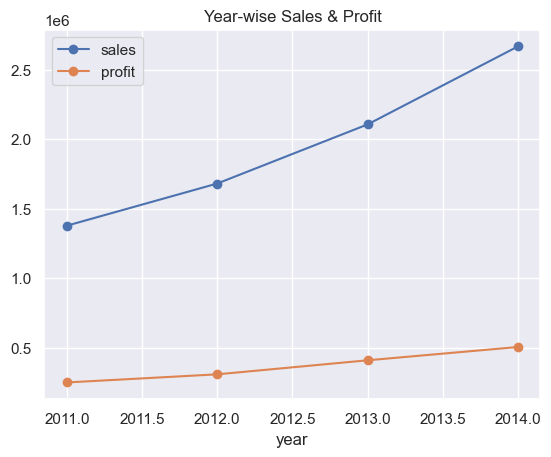

In [46]:
# Year-wise Analysis
yearly = df.groupby('year')[['sales','profit']].sum()

print("\n📈 Year-wise Sales & Profit:\n", yearly)

yearly.plot(marker='o', title="Year-wise Sales & Profit")
plt.savefig("Plots/yearly_sales_profit.png")
plt.show()


📅 Monthly Sales:
 Month
1     475695.0
2     455796.0
3     557679.0
4     531722.0
5     592614.0
6     745063.0
7     554111.0
8     736964.0
9     783356.0
10    697796.0
11    877597.0
12    826735.0
Name: sales, dtype: float64


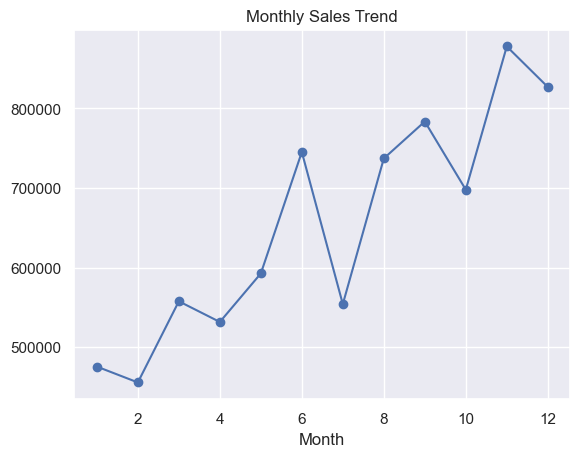

In [47]:
# Monthly Trend
monthly = df.groupby('Month')['sales'].sum()

print("\n📅 Monthly Sales:\n", monthly)

monthly.plot(marker='o', title="Monthly Sales Trend")
plt.savefig("Plots/monthly_sales_trend.png")
plt.show()


Region Analysis:
                     sales        profit
region                                 
Africa           538115.0   88871.63100
Canada            50314.0   17817.39000
Caribbean        251441.0   34571.32104
Central         1806638.0  311403.98164
Central Asia     389506.0  132480.18700
EMEA             575562.0   43897.97100
East             366492.0   91522.78000
North            790546.0  194597.95252
North Asia       453686.0  165578.42100
Oceania          625382.0  121666.64200
South           1031101.0  140355.76618
Southeast Asia   532172.0   17852.32900
West             424173.0  108418.44890


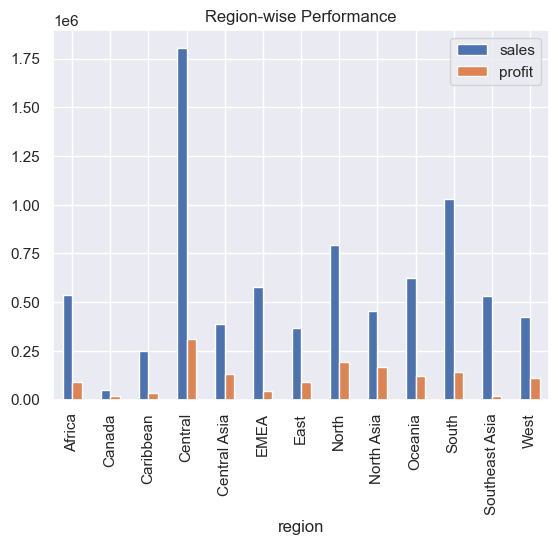

In [48]:
# Region-wise Analysis
region = df.groupby('region')[['sales','profit']].sum()

print("\nRegion Analysis:\n", region)

region.plot(kind='bar', title="Region-wise Performance")
plt.savefig("Plots/region_performance.png")
plt.show()


🌐 Market Analysis:
             sales        profit
market                         
APAC    2000746.0  437577.57900
Africa   538115.0   88871.63100
Canada    50314.0   17817.39000
EMEA     575562.0   43897.97100
EU      1803099.0  372829.74150
LATAM   1563126.0  221643.48708
US      1304166.0  286397.02170


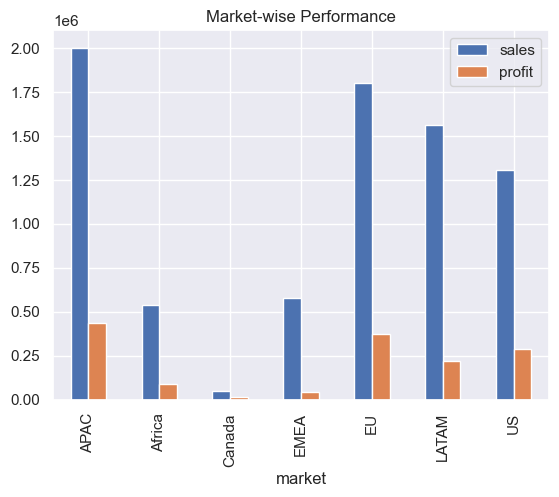

In [49]:
# Market Analysis
market = df.groupby('market')[['sales','profit']].sum()

print("\n🌐 Market Analysis:\n", market)

market.plot(kind='bar', title="Market-wise Performance")
plt.savefig("Plots/market_performance.png")
plt.show()


📦 Category Analysis:
                      sales        profit
category                                
Furniture        2406605.0  286782.25380
Office Supplies  2790258.0  518473.83430
Technology       2638265.0  663778.73318


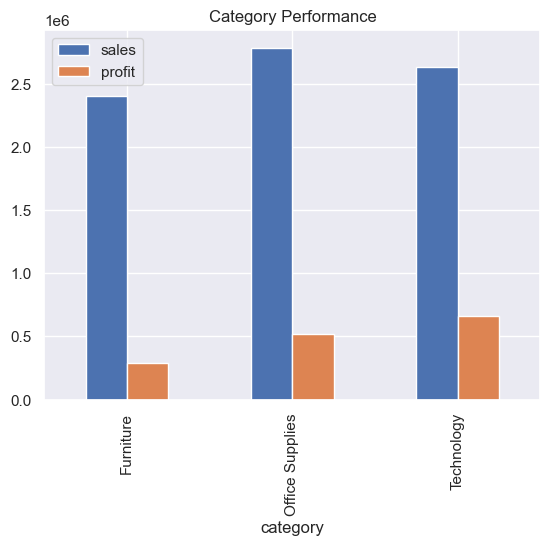

In [50]:
# Category Analysis
category = df.groupby('category')[['sales','profit']].sum()

print("\n📦 Category Analysis:\n", category)

category.plot(kind='bar', title="Category Performance")
plt.savefig("Plots/category_performance.png")
plt.show()


📊 Sub-category Profit:
 sub_category
Tables         -64083.38870
Fasteners       11525.42410
Labels          15010.51200
Supplies        22583.26310
Envelopes       29601.11630
Furnishings     46967.42550
Art             57953.91090
Machines        58867.87300
Paper           59207.68270
Binders         72449.84600
Storage        108461.48980
Accessories    129626.30620
Appliances     141680.58940
Chairs         141973.79750
Bookcases      161924.41950
Phones         216717.00580
Copiers        258567.54818
Name: profit, dtype: float64


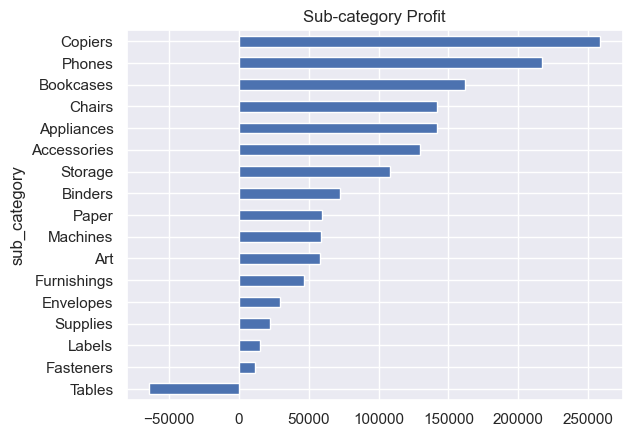

In [51]:
# Sub-category Analysis
subcat = df.groupby('sub_category')['profit'].sum().sort_values()

print("\n📊 Sub-category Profit:\n", subcat)

subcat.plot(kind='barh', title="Sub-category Profit")
plt.savefig("Plots/subcategory_profit.png")
plt.show()


🛍️ Top Products:
 product_name
Eldon File Cart, Single Width                         31319.0
Rogers File Cart, Single Width                        22645.0
Tenex File Cart, Single Width                         20778.0
Smead File Cart, Single Width                         20775.0
Office Star Executive Leather Armchair, Adjustable    19355.0
Fellowes Lockers, Industrial                          19172.0
Smead Lockers, Industrial                             18648.0
Hewlett Copy Machine, Color                           16849.0
Rogers Lockers, Blue                                  16494.0
Fellowes Lockers, Wire Frame                          16470.0
Name: sales, dtype: float64


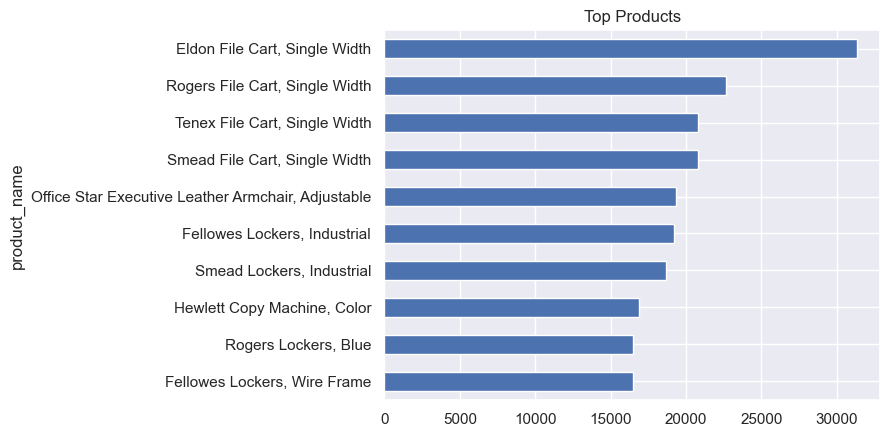

In [52]:
# Top Products
top_products = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)

print("\n🛍️ Top Products:\n", top_products)

top_products.plot(kind='barh', title="Top Products")
plt.gca().invert_yaxis()
plt.savefig("Plots/top_products.png")
plt.show()

In [53]:
# Loss-making Products
loss_products = df[df['profit'] < 0]

print("\n❗ Loss-making Products:\n")
print(loss_products[['product_name','sales','profit','profit_margin']].head())



❗ Loss-making Products:

                                 product_name  sales    profit  profit_margin
3                 Enermax Note Cards, Premium   45.0  -26.0550      -0.579000
8                 Hewlett Wireless Fax, Laser  912.0 -319.4640      -0.350289
10                  Tenex Lockers, Industrial  338.0 -122.8005      -0.363315
11  Chromcraft Round Table, Adjustable Height  211.0  -70.3995      -0.333647
14              Hon Rocking Chair, Set of Two  159.0  -95.6760      -0.601736


In [54]:
# Total Loss Rows
print("\nTotal loss-making rows:", (df['profit'] < 0).sum())


Total loss-making rows: 12543



🚚 Shipping Days:
 ship_mode
First Class       3.486742
Same Day          0.069974
Second Class      4.155010
Standard Class    6.216507
Name: shipping_days, dtype: float64


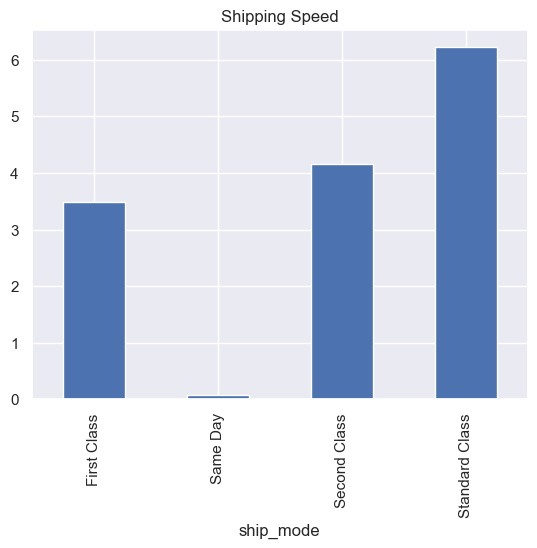

In [55]:
# Shpping Analysis
shipping = df.groupby('ship_mode')['shipping_days'].mean()

print("\n🚚 Shipping Days:\n", shipping)

shipping.plot(kind='bar', title="Shipping Speed")
plt.savefig("Plots/shipping_speed.png")
plt.show()

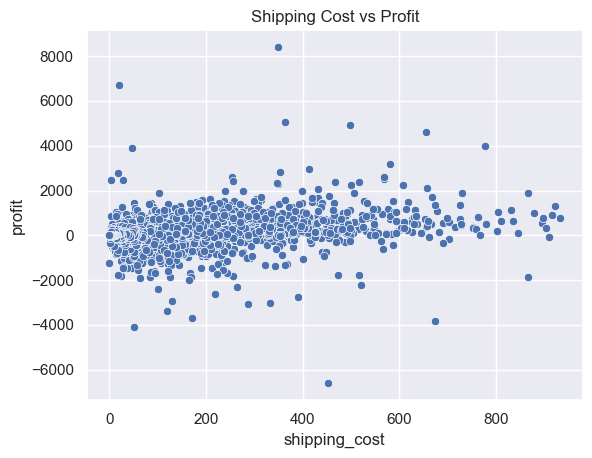

In [56]:
# Shipping Cost vs Profit
sns.scatterplot(x=df['shipping_cost'], y=df['profit'])
plt.title("Shipping Cost vs Profit")
plt.savefig("Plots/shipping_cost_profit.png")
plt.show()


📊 Order Priority:
                     sales        profit
order_priority                         
Critical         598854.0  125801.69428
High            2365250.0  420373.51340
Low              379567.0   58655.85098
Medium          4491457.0  864203.76262


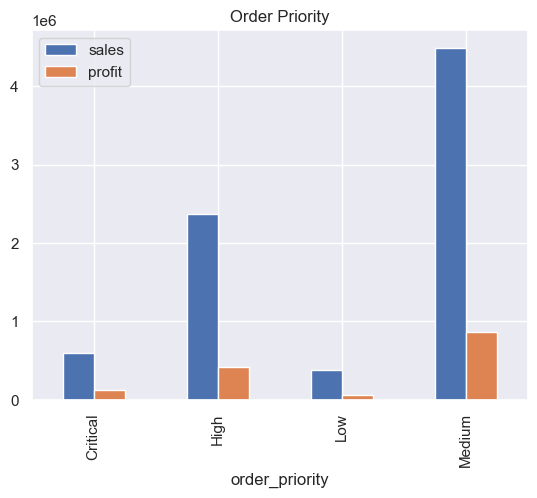

In [57]:
# Order Priority
priority = df.groupby('order_priority')[['sales','profit']].sum()

print("\n📊 Order Priority:\n", priority)

priority.plot(kind='bar', title="Order Priority")
plt.savefig("Plots/order_priority.png")
plt.show()


Pareto Top Products:
 product_name
Eldon File Cart, Single Width                         0.089128
Rogers File Cart, Single Width                        0.153571
Tenex File Cart, Single Width                         0.212701
Smead File Cart, Single Width                         0.271822
Office Star Executive Leather Armchair, Adjustable    0.326903
Fellowes Lockers, Industrial                          0.381462
Smead Lockers, Industrial                             0.434531
Hewlett Copy Machine, Color                           0.482480
Rogers Lockers, Blue                                  0.529418
Fellowes Lockers, Wire Frame                          0.576289
Hon Executive Leather Armchair, Adjustable            0.621614
Sharp Copy Machine, Color                             0.666563
Brother Copy Machine, Color                           0.711333
Bush Stackable Bookrack, Pine                         0.755819
Harbour Creations Swivel Stool, Red                   0.799698
HP Copy Machine, Co

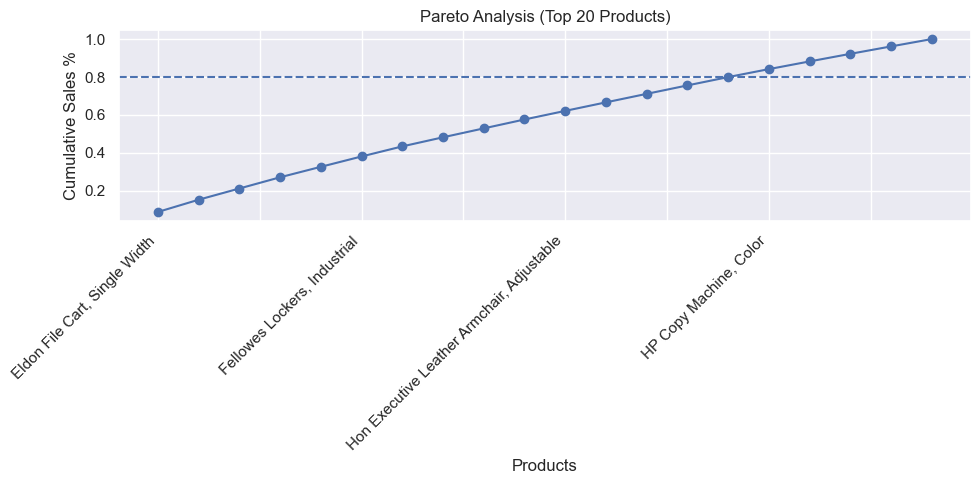

In [58]:
# Pareto Analysis
# Top 20 products only
product_sales = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(20)

cumulative = product_sales.cumsum() / product_sales.sum()

print("\nPareto Top Products:\n", cumulative)

# Plot
plt.figure(figsize=(10,5))
cumulative.plot(marker='o')

plt.axhline(0.8, linestyle='--')
plt.title("Pareto Analysis (Top 20 Products)")
plt.xlabel("Products")
plt.ylabel("Cumulative Sales %")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("Plots/pareto_analysis.png")

plt.show()


Correlation:
                   sales    profit  quantity  shipping_cost
sales          1.000000  0.252703  0.276072       0.771133
profit         0.252703  1.000000  0.104743       0.357033
quantity       0.276072  0.104743  1.000000       0.272649
shipping_cost  0.771133  0.357033  0.272649       1.000000


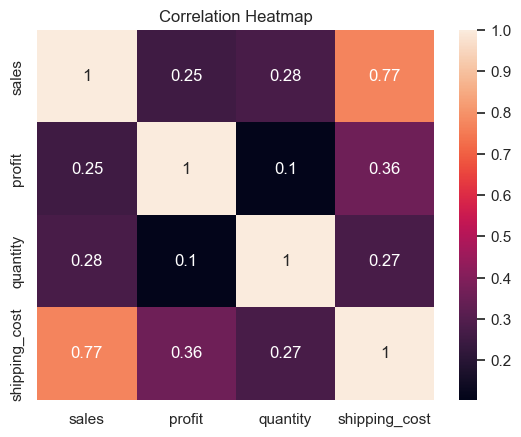

In [59]:
# Correlation Heatmap
print("\nCorrelation:\n", df[['sales','profit','quantity','shipping_cost']].corr())

sns.heatmap(df[['sales','profit','quantity','shipping_cost']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.savefig("Plots/correlation_heatmap.png")
plt.show()

In [60]:
# Customer Segmentation
df['customer_level'] = pd.qcut(df['sales'], q=3, labels=['Low','Medium','High'])

segment = df.groupby('customer_level')['sales'].sum()

print("\n👥 Customer Segmentation:\n", segment)


👥 Customer Segmentation:
 customer_level
Low        344565.0
Medium    1328850.0
High      6161713.0
Name: sales, dtype: float64


# Sales Data Analysis – End-to-End Capstone Project

## Objective
The objective of this project is to analyze sales data to identify key trends, top-performing products, regional performance, and profitability patterns. The goal is to generate actionable insights that can help improve business decisions.

## Data Cleaning & Preparation
- Converted date columns into proper datetime format
	•	Handled missing and inconsistent values
	•	Converted sales and profit into numeric format
	•	Created new features:
	•	Month
	•	Year
	•	Shipping Days
	•	Profit Margin

## Key Performance Indicators (KPIs)
•	Total Sales: (7835128.0)
	•	Total Profit: (1469034.82128)
	•	Total Orders: (25035)
	•	Total Quantity Sold: (178312)
	•	Average Order Value: (y312.9669662472538)
	•	Average Profit Margin: (0.0419385808037921)

## Key Insights
1. Sales Trend Analysis
	•	Sales show variation across months and years
	•	Certain months have significantly higher sales (seasonality present)
👉 Suggests demand is season-driven

2. Regional Performance
	•	Some regions generate higher sales and profit than others
	•	Few regions may have high sales but low profit
👉 Indicates cost inefficiency or pricing issues

3. Category & Sub-category Insights
	•	Certain categories contribute most to revenue
	•	Some sub-categories are loss-making ❗
👉 Business should:
	•	Promote profitable categories
	•	Review or discontinue loss-making ones

4. Product Performance (Pareto Analysis)
	•	Top products contribute to majority of sales (~80%)
👉 Confirms Pareto Principle (80/20 rule)
👉 Focus marketing on high-performing products

5. Profitability Analysis
	•	Presence of negative profit margins indicates losses
👉 Possible reasons:
	•	High discounts
	•	High shipping costs
	•	Poor pricing strategy

6. Shipping & Delivery Analysis
	•	Shipping days vary by shipping mode
👉 Faster shipping modes improve delivery time but may increase cost

7. Shipping Cost Impact
	•	Higher shipping cost may reduce profit
👉 Need to optimize logistics

8. Customer Segmentation
	•	Customers grouped into Low, Medium, High spending
👉 High-value customers contribute major revenue
👉 Should be targeted for retention

 📌 RECOMMENDATIONS 
	1.	Focus on top-performing products to maximize revenue
	2.	Reduce or improve loss-making products
	3.	Optimize shipping cost to improve profit margins
	4.	Target high-value customers with offers and loyalty programs
	5.	Improve performance in low-performing regions
	6.	Analyze seasonal trends for better inventory planning

🏁 Conclusion

This project successfully analyzed sales data and uncovered key business insights. By leveraging data-driven decisions, the company can improve profitability, optimize operations, and enhance customer satisfaction.